In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import yfinance as yf
from datetime import timedelta
from sklearn.mixture import GaussianMixture #For limit order price
import matplotlib.pyplot as plt
import scipy.special as sp #For hypergeometric functions

# Data Handling

This section assumes you have a csv data set with the following columns:
- ts_event: The matching-engine-received timestamp expressed as the number of nanoseconds since the UNIX epoch.
- bid_fill: Amount of bid-side orders accepted for the time step
- ask_fill: Amount of ask-side orders accepted for the time step
- Signed Volume: Bid fill - Ask Fill (Just the difference)
- price: The order price adjusted to unit dollars (from 1e-9 dollars)
- best_bid: Best offer to buy the stock at the particular timestep
- best_ask: Best offer to sell the stock at the particular timestep
- mid_price: (best_bid + best_ask) / 2

The data is procured from DataBento by the data curation team. The data columns shown here cannot be directly downloaded from DataBento, some processing is required.

Data is stored in the 'Data' folder for organizational purposes.

It is highly reccommended to get the 'Data Wrangler' extension in VScode or Cursor. It makes it easy to visualize Pandas Dataframes.

IMPORTANT: When using a specific ticker csv, you must also update the Yahoo Finance API call to the correct ticker.

Note: Calculating the spread from the base data set THEN aggregating seems to give the same result as calculating the spread from the aggregated values. This makes sense =) 

In [ ]:
# Start with your data
# Read the CSV in chunks
chunk_size = 1000  # Adjust this size based on your memory capacity
df_chunks = pd.read_csv('Data/aapl-mbp-10.csv', chunksize=chunk_size)

# Concatenate chunks into a single DataFrame
df = pd.concat(df_chunks, ignore_index=True)

df['ts_event'] = pd.to_datetime(df['ts_event'], format='mixed', utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
df['Timestamp'] = pd.to_datetime(df['ts_event'])
df['Date'] = df['Timestamp'].dt.date

# Calculate the earliest and latest dates in 'df'
earliest_date = df['Date'].min()
latest_date = df['Date'].max()

# Adjust 'start_date' and 'end_date' based on 'df'
start_date = earliest_date - timedelta(days=30)  # Earliest date minus 30 days
end_date = latest_date + timedelta(days=1)       # Latest date plus 1 day
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

# code to download daily volume
# ALSO MUST UPDATE THIS WHEN CHANGING DATA
data = yf.download('AAPL', start=start_date_str, end=end_date_str, interval='1d')
data = data.reset_index()

# Handle MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(level=1)
data = data.dropna()

# Ensure 'Date' column in 'data' matches the format in 'df'
data['Date'] = data['Date'].dt.date
merged_df = pd.merge(df, data, on='Date', how='left')
merged_df.head()

In [ ]:
# Take just the columns you need
merged_df = merged_df[['ts_event','bid_fill','ask_fill','best_bid','best_ask']]

market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

# Set 'ts_event' as the index
merged_df.set_index('ts_event', inplace=True)
# Filter data between market open and close times
df_market = merged_df.between_time(market_open_time, market_close_time)

# Aggregation
# IMPORTANT: CHANGE FREQUENCY HERE
df_agg = df_market.resample('1s').agg({
    'bid_fill': 'sum',
    'ask_fill': 'sum',
    'best_bid': 'max',
    'best_ask': 'min'
})
df_agg = df_agg.dropna(subset=['best_bid']) # downsample will fill NaNs to out-of-market hours
df_agg = df_agg.reset_index()
df_agg['mid_price'] = (df_agg['best_bid'] + df_agg['best_ask']) / 2
df_agg['Spread'] = df_agg['best_ask'] - df_agg['best_bid']
print(df_agg.head(), f"df_agg.shape is: {df_agg.shape}")

# Market and Limit Order Parameters

## Intensities

#### Some Notes:
- q1 and Q10 are on the side of submission:
    - Ask for buy market order
    - Bid for sell market order
        - Basically we will need to train $\lambda^{M} \ \& \ \lambda^{L}$ seperately for buy side and sell side. 
- We do not modify any order. Only place and cancel. 
- Order places between two time ticks are rounded up to the nearest tick in the book. 
    - Order can arrive at the same time
Example Dataset (1 second is the minimum time between changes).
We only need the top level order book for each time. 

Example Limit Order Book(top level only): 
| Time | Bid Price | Bid Quantity | Ask Price | Ask Quantity |
|------|-----------|--------------|-----------|--------------|
|0 | 200 | 5 | 150  | 10 |
|1 | 201   | 5  | 151  | 10 |
|2 | 201   | 5  | 150  | 10 | #
|3 | 201 | 4 | 149 | 12 | #*
|4 | 201 | 4| 149 | 12 |
| 5 | 201 | 5 | 149 | 9 | 

From the above book the limit order arrival times are: 
|Time|Side|Price|Quantity|
|----|----|------|-------|
|0|Sell|200|5|
|0|Buy|150|10|
|1|Sell|201|5|
|1|Buy|151|10|
|2|Buy|151|10|
|3|Buy|149|12|


Example Market Order Arrival:
|Time| Side | Quantity |
|----|------|----------|
|2|Sell|1|
|4|Buy|3|

For market orders the following information is relavent:
- Times when spread changed: 0,2,3 
- Times when q1 changes: 0, 3, 5
- Times when ask side market orders arrived: 4
- Times when bid side market orders have arrived: 2

For limit orders the following information is relavent: 
- Times when spread changed: 0,2,3 
- Times when q1 changes: 0, 3, 5
- Times when bid side limit orders have arrived: 0, 1
- Times when ask side limit orders have arrived: 0, 1, 2, 3

#### Code

The following codeblock contains the ML functions. The notation is as follows: 
- Let 'T' be the total time(in seconds) on which we we want to train the model(not used directly)
    - Let the smallest time-step be one second
- 'N' is the total number of market orders that have arrived in T
- S in an array of length T that contains the spread at each second (index 0 to T-1)
- q_1 is an array of length T that contains the spread at each second
- t_M is an array of the times a market order has arrived
- t_L is an array of the times a limit order has arrived
- t_q1 is an array of the times the level 1 submission side volume has changed(not used directly)
- t is the union of t_M(or t_L) and t_q1

B specifies bid side
A specifies ask side

In [2]:
def ML_Func(beta, N, S, q_1, t_M, t):
    
    #Required Parameters
    beta0, beta1, beta11, beta2, beta22, beta12 = beta
    
    #Left Hand limit(don't need to worry about -1 index as no order is going to be placed at t=0)
    #t_M = t_M - 1 
    #t = t - 1

    # Compute first term
    first_term = beta0 * N + \
                 beta1 * np.sum(np.log(S[t_M])) + \
                 beta11 * np.sum((np.log(S[t_M]))**2) + \
                 beta2 * np.sum(np.log(1 + q_1[t_M])) + \
                 beta22 * np.sum((np.log(1 + q_1[t_M]))**2) + \
                 beta12 * np.sum(np.log(S[t_M]) * np.log(1 + q_1[t_M]))
    
    # Compute second term
    exp_terms = np.exp(beta0 + 
                       beta1 * np.log(S[t]) + 
                       beta11 * (np.log(S[t]))**2 + 
                       beta2 * np.log(1 + q_1[t]) + 
                       beta22 * (np.log(1 + q_1[t]))**2 + 
                       beta12 * np.log(S[t]) * np.log(1 + q_1[t]))
    
    t = np.insert(t, 0, 0) #This to make sure we get the correct difference
    second_term = np.sum(exp_terms * (t[1:] - t[:-1]))
    
    # Return negative log-likelihood
    return -(first_term - second_term)


To Ease Calculation and prevent overflow we normalise the data with a specfic value(median in my case): 
- Devide Price by: 175.25
    - Bid Side Median Price : 201
    - Ask Side Median Price : 149.5

- Devide Volume by: 8
    - Bid Side Median Quantity: 5
    - Ask Side Median Quantity: 11

Revised Book: 
| Time | Bid Price | Bid Quantity | Ask Price | Ask Quantity |
|------|-----------|--------------|-----------|--------------|
|0 | 1.141 | 0.625 | 0.856  | 1.25 |
|1 | 1.147  | 0.625  | 0.861  | 1.25 |
|2 | 1.147   | 0.625  | 0.856  | 1.25 | #
|3 | 1.147 | 0.5 | 0.850 | 1.5 | #*
|4 | 1.147 | 0.5| 0.850 | 1.5 |
|5 | 1.147 | 0.625 | 0.850 | 1.125 | 

#### Ask Side Market Order

Using Data From Example Given Above: (Calculating the buy side market order intensity)

In [3]:
T_AM = 6 # Total time during which the spread is equal to S in the sample
N_AM = 1 # Total number of market orders submitted when the spread is equal to S
S_AM = np.array([0.285, 0.286, 0.291, 0.297, 0.297, 0.297]) # Spread between best_bid and best_ask
q_1_AM = np.array([1.25, 1.25, 1.25, 1.5, 1.5, 1.125]) # Volume of the best quote (on the side of submission, ask for a buy market order, bid for a sell market order)
t_M_AM = np.array([4]) # Set of arrival times of market orders in our sample
t_q1_AM = np.array([3,5]) # Exclude t = 0 as that is the initial position. set of times of jumps of the first limit process q_1
t_AM = np.union1d(t_M_AM, t_q1_AM) # Combined array

In [4]:
# Initial guesses for beta parameters
initial_beta_AM = np.zeros(6)

# Optimize
result_AM = minimize(ML_Func, initial_beta_AM, args=(N_AM, S_AM, q_1_AM, t_M_AM, t_AM,), method='L-BFGS-B')

# Extract results
optimal_beta_AM = result_AM.x
print("Optimal Parameters:", optimal_beta_AM)


Optimal Parameters: [-12.25793592  14.88132536 -18.06632109  13.20730055  30.52324656
 -16.03406334]


Calculating the Market Order Intensity

In [5]:
lam_M_ask = lambda S,q1: np.exp(optimal_beta_AM[0] + optimal_beta_AM[1]*np.log(S) + optimal_beta_AM[2]*(np.log(S))**2 + optimal_beta_AM[3]*np.log(1+q1) + optimal_beta_AM[4]*(np.log(1+q1))**2 + optimal_beta_AM[5]*np.log(S)*np.log(1+q1))

In [6]:
lam_M_ask(0.297,1.125)

np.float64(3.11820040352535e-07)

#### Bid Side Market Order

In [7]:
T_BM = 6 # Total time during which the spread is equal to S in the sample
N_BM = 1 # Total number of market orders submitted when the spread is equal to S
S_BM = np.array([0.285, 0.286, 0.291, 0.297, 0.297, 0.297]) # Spread between best_bid and best_ask
q_1_BM = np.array([0.625, 0.625, 0.625, 0.5, 0.5, 0.625]) # Volume of the best quote (on the side of submission, ask for a buy market order, bid for a sell market order)
t_M_BM = np.array([2]) # Set of arrival times of market orders in our sample
t_q1_BM = np.array([3,5]) # Exclude t = 0 as that is the initial position. set of times of jumps of the first limit process q_1
t_BM = np.union1d(t_M_BM, t_q1_BM) # Combined array

In [8]:
# Initial guesses for beta parameters
initial_beta_BM = np.zeros(6)

# Optimize
result_BM = minimize(ML_Func, initial_beta_BM, args=(N_BM, S_BM, q_1_BM, t_M_BM, t_BM,), method='L-BFGS-B')

# Extract results
optimal_beta_BM = result_BM.x
print("Optimal Parameters:", optimal_beta_BM)


Optimal Parameters: [-658.13853482  303.30802499  243.66549012  341.34916747  433.69107948
 -655.06742359]


In [9]:
lam_M_bid = lambda S,q1: np.exp(optimal_beta_BM[0] + optimal_beta_BM[1]*np.log(S) + optimal_beta_BM[2]*(np.log(S))**2 + optimal_beta_BM[3]*np.log(1+q1) + optimal_beta_BM[4]*(np.log(1+q1))**2 + optimal_beta_BM[5]*np.log(S)*np.log(1+q1))

In [10]:
lam_M_bid(0.297,1.125)

np.float64(2.0899904797127882e+189)

### Ask Side Limit Order

On replacing q_1 with Q_10, we can get limit order intensities!
Using a simple example: Q10 = 10*q1

In [11]:
T_AL = 6 # Total time during which the spread is equal to S in the sample
N_AL = 1 # Total number of market orders submitted when the spread is equal to S
S_AL = np.array([0.285, 0.286, 0.291, 0.297, 0.297, 0.297]) # Spread between best_bid and best_ask
q_1_AL = np.array([1.25, 1.25, 1.25, 1.5, 1.5, 1.125]) # Volume of the best quote (on the side of submission, ask for a buy market order, bid for a sell market order)
t_L_AL = np.array([1,2,3]) # Set of arrival times of limit orders in our sample
t_q1_AL = np.array([3,5]) # Exclude t = 0 as that is the initial position. set of times of jumps of the first limit process q_1
t_AL = np.union1d(t_L_AL, t_q1_AL) # Combined array

In [12]:
# Initial guesses for beta parameters
initial_beta_AL = np.zeros(6)

# Optimize
result_AL = minimize(ML_Func, initial_beta_AL, args=(N_AL, S_AL, q_1_AL*10, t_L_AL, t_AL,), method='L-BFGS-B')

# Extract results
optimal_beta_AL = result_AL.x
print("Optimal Parameters:", optimal_beta_AL)

Optimal Parameters: [-1.51318761e+25  6.98722509e+23 -6.48289235e+23 -4.54969238e+23
  2.42398670e+24  1.34512425e+23]


Calculating the Limit Order Intensity

In [13]:
lam_L_ask = lambda S,q1: np.exp(optimal_beta_AL[0] + optimal_beta_AL[1]*np.log(S) + optimal_beta_AL[2]*(np.log(S))**2 + optimal_beta_AL[3]*np.log(1+q1) + optimal_beta_AL[4]*(np.log(1+q1))**2 + optimal_beta_AL[5]*np.log(S)*np.log(1+q1))

In [14]:
lam_L_ask(0.297,1.125*10)

np.float64(0.0)

### Bid side Limit Order

In [15]:
T_BL = 6 # Total time during which the spread is equal to S in the sample
N_BL = 1 # Total number of market orders submitted when the spread is equal to S
S_BL = np.array([0.285, 0.286, 0.291, 0.297, 0.297, 0.297]) # Spread between best_bid and best_ask
q_1_BL = np.array([0.625, 0.625, 0.625, 0.5, 0.5, 0.625]) # Volume of the best quote (on the side of submission, ask for a buy market order, bid for a sell market order)
t_L_BL = np.array([1]) # Set of arrival times of limit orders in our sample
t_q1_BL = np.array([3,5]) # Exclude t = 0 as that is the initial position. set of times of jumps of the first limit process q_1
t_BL = np.union1d(t_L_BL, t_q1_BL) # Combined array

In [16]:
# Initial guesses for beta parameters
initial_beta_BL = np.zeros(6)

# Optimize
result_BL = minimize(ML_Func, initial_beta_BL, args=(N_BL, S_BL, q_1_BL*10, t_L_BL, t_BL,), method='L-BFGS-B')

# Extract results
optimal_beta_BL = result_BL.x
print("Optimal Parameters:", optimal_beta_BL)

Optimal Parameters: [-119.69499799   38.61874812   86.6683157  -109.0622928    13.38750077
  -78.93935744]


In [17]:
lam_L_bid = lambda S,q1: np.exp(optimal_beta_BL[0] + optimal_beta_BL[1]*np.log(S) + optimal_beta_BL[2]*(np.log(S))**2 + optimal_beta_BL[3]*np.log(1+q1) + optimal_beta_BL[4]*(np.log(1+q1))**2 + optimal_beta_BL[5]*np.log(S)*np.log(q1))

In [18]:
lam_L_bid(0.297,1.125*10)

np.float64(49.15957163477983)

## Limit Order Price

#### Notes: 
- In the example used above, we only have the top level order book. There would be limit orders that doen't reach the top. Those cases are not present in the example, but would need to be taken into account
- To model price we would need an array of all the limit order placed, with the distances(absolute value) from the current best price. We would then fit a GMM(G=3) model on it.

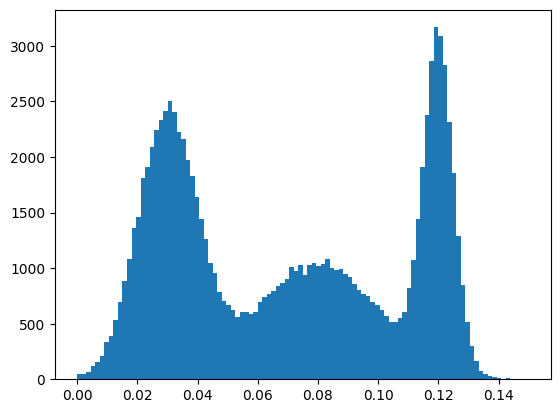

In [19]:
#Using Example Data
import numpy as np

# Parameters for the three Gaussian peaks
np.random.seed(42)  # For reproducibility
n_samples = 1e5  # Number of data points

# Define the means, standard deviations, and weights for the Gaussian mixture
means = [0.03, 0.08, 0.12]
std_devs = [0.01, 0.02, 0.005]
weights = [0.4, 0.35, 0.25]

# Generate data for each Gaussian
data = np.concatenate([
    np.random.normal(mean, std, int(weight * n_samples))
    for mean, std, weight in zip(means, std_devs, weights)
])

# Clip data to stay within the range [0, 0.15]
data = data[(data >= 0) & (data <= 0.15)]

plt.hist(data, bins = 100)
plt.show()

Fitting a gaussian mixture model

In [20]:
# Fit a Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=3, random_state=None)
data_reshaped = data.reshape(-1, 1)
gmm.fit(data_reshaped)

GaussianMixture(n_components=3)

Showing the fitted values

In [21]:
gmm.means_.flatten(), np.sqrt(gmm.covariances_).flatten(), gmm.weights_

(array([0.03070976, 0.11964933, 0.0799799 ]),
 array([0.01044882, 0.00563065, 0.01646031]),
 array([0.41987901, 0.27159412, 0.30852687]))

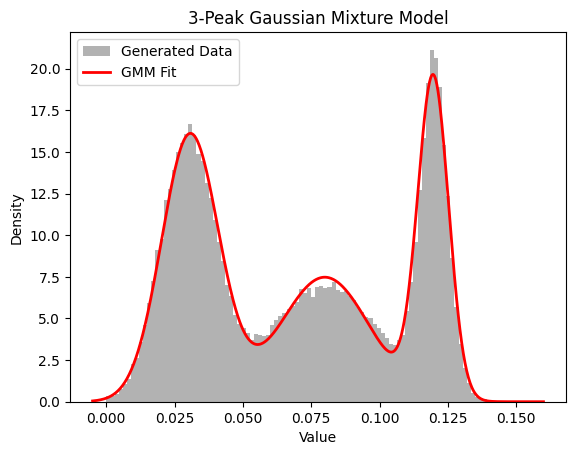

In [22]:
# Predict the components and plot the histogram with the fitted GMM
x = np.linspace(-0.005, 0.16, 800).reshape(-1, 1)
density = np.exp(gmm.score_samples(x))

# Plotting the results
plt.hist(data, bins=100, density=True, alpha=0.6, color='gray', label='Generated Data')
plt.plot(x, density, color='red', lw=2, label='GMM Fit')
plt.title('3-Peak Gaussian Mixture Model')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

To Random Sample from the GMm

In [23]:
gmm.sample(1)[0].flatten().tolist()[0]

0.1164589393435099

Follow the procedure in this section to generate the distribution and sample from it. 

# Cancellations 

- Theta is the value we want to get
- The lambdas are calculated above
- The sigmas are estimated by median size of limit/market order

We cannot simply model cancelations in the same way as market or limit orders, since we can only cancel orders at prices where some orders are actually
standing in the book. Instead, we can model the 'lifetime' of an order, and cancel orders at an equivalent rate. We want the average lifetime of an order to be computed so that a basic order book model with Poisson intensities would have an average total liquidity in the book equal to the empirical observation. We model the total liquidity Q, with a tuned parameter theta to equal empirical observations. 

Once we know how often to cancel orders, we need to know which orders to cancel. The authors introduce a 'priority index' xi. Xi tells us how close an order is to the front of the queue. 0 means it is next in line to be executed (best sided price), while 1 means it is at the back of the queue. 


Let's say we're looking at two consecutive snapshots of the order book. At the ask price of $180.50, we see:

At 9:30:00: Volume of 1000 shares
At 9:30:01: Volume of 800 shares

This 200-share decrease could represent a cancellation. At the moment this cancellation occurred, we can calculate its xi value by looking at the state of the order book at 9:30:01:

For this cancelled order at $180.50, we look at all ask prices:

Volume at better prices (below $180.50): Let's say 500 shares
Volume at the same price ($180.50): 800 shares (the authors assume the canceled order was in the middle, so we count half): 400 shares
Total volume in the book: Let's say 2000 shares

Therefore xi = (500 + 400) / 2000 = 0.45

We can repeat this for many prices (180.51, 180.52, 180.49, etc...) and for different time steps (between 9:30:01 and 9:30:02, 9:30:02 and 9:30:03, etc).


We build up a collection of these $\xi$ values and ask, is there a pattern here? It turns out, yes! If you treat $\xi$as a random variable, it probability distribution looks like ![My Image](Image.png)


Think of this equation as a malleable blob of playdoh. It gives us the general shape of the probability distribution, but we need to mold it to fit our exact data. Maybe the amplitude needs to be higher in one part and the tail longer in another.

For each cancellation, you can plug its $\xi$ value into the equation above to get the probability of that cancellation occurring according to your model. The log-likelihood function (attachment:image-3.png) essentially multiplies all these probabilities together (or adds their logarithms, which is mathematically equivalent but numerically more stable).
The higher the log-likelihood value, the better your model explains the observed data. Therefore, by finding the values of α and σ that maximize equation 16, you're finding the parameters that make your model best match reality.

Steps:
1. Take our MBP-10 data
2. for a single time step, iterate through different price values on a single side and calculate the $\xi$values (and store in an array)
3. Increment a time step and repeat step 2
4. At the end of this, you should have a collection of $\xi$ values
5. Use the second equation (16) to minimize the negative of the log-likelihoods
6. Take the resulting alpha and sigma values and use in equation (15)

Now we are left with a pdf of $\xi$, and various $\xi$ values for the orders from our order book. Every time a cancellation happens, we sample from this distribution get $\bar{\xi}$. We cancel the first order that has a priority index greater than or equal to $\bar{\xi}$(for ask that is top-down). 


The three code blocks below need to be checked with real data(right now we are getting 0 for Q, which is wrong)

In [44]:
def liquidity_Q(theta, emp_Q, lam_M, lam_L, sig_M, sig_L):
    v = lam_L/theta
    delta = lam_M/theta
    q = sig_M/sig_L

    Q = sig_M*(v/q - delta + (delta*q**(v/(1-q))) / (sp.hyp2f1(delta, (-v/(1-q)), 1+delta, 1-q)))

    #Minimising a LSE
    return np.sum((emp_Q - Q)**2) 

In [47]:
def Opt_Theta(emp_Q, lam_M, lam_L, sig_M, sig_L, initial_guess = 1):
    # Perform the optimization to find the best a
    result = minimize(liquidity_Q, initial_guess, args=(emp_Q, lam_M, lam_L, sig_M, sig_L,))
    
    # Get the optimal value of a
    optimal_theta = result.x[0]
    return optimal_theta

In [48]:
Opt_Theta(8,lam_M_ask(0.297,1.125), lam_L_ask(0.297,1.125*10),2, 10)

np.float64(1.0)

##### Class Implementation:

In [2]:
class OrderBook:
    def __init__(self):
        # Dictionary to store ask side: price -> volume
        self.asks = {}
        # Dictionary to store bid side: price -> volume
        self.bids = {}
        
    def add_order(self, side, price, volume):
        """Add an order to the book."""
        if side == 'ask':
            self.asks[price] = self.asks.get(price, 0) + volume
        else:  # bid
            self.bids[price] = self.bids.get(price, 0) + volume

    def calculate_priority_index(self, side, price):
        """
        Calculate the priority index (ξ) for an order at the given price.
        
        Args:
            side: 'ask' or 'bid'
            price: Price level of the order
            
        Returns:
            float: Priority index between 0 and 1
        """
        if side == 'ask':
            book = self.asks
            better_prices = [p for p in book.keys() if p < price]  # Lower ask prices have priority
        else:  # bid
            book = self.bids
            better_prices = [p for p in book.keys() if p > price]  # Higher bid prices have priority
            
        # Calculate priority volume
        # 1. Sum of volume at better prices
        better_volume = sum(book[p] for p in better_prices)
        # 2. Half of volume at same price
        same_price_volume = book.get(price, 0) * 0.5
        priority_volume = better_volume + same_price_volume
        
        # Calculate total volume in the book
        total_volume = sum(book.values())
        
        # Calculate priority index
        if total_volume == 0:
            return 0.0
        
        return priority_volume / total_volume

def calculate_priority_indices_from_cancellations(cancellations, order_book):
    """
    Calculate priority indices for a list of cancellations.
    
    Args:
        cancellations: List of tuples (side, price, volume)
        order_book: OrderBook instance with the state before each cancellation
        
    Returns:
        List of priority indices
    """
    priority_indices = []
    
    for side, price, _ in cancellations:
        xi = order_book.calculate_priority_index(side, price)
        priority_indices.append(xi)
        
    return priority_indices

I am a little confused as to why there is a volume associated with cancellations. I'll explain my doubts with an example. 

Placing Ask Side Limit Orders:
(each ID is a player)
|ID|TIME|Price|Quantity|
|---|---|---|----|
|1|3:00:00|150|10|
|2|3:00:01|150|15|
|3|3:00:02|155|20|
|4|3:00:03|160|5|
|5|3:00:04|165|10|

Now, player 2(ID=2) decides to cancel their order at t=3:00:03. This is how the order book would evolve. 

Ask Side Order Book:

At t= 3:00:00
|Level|Price|Quantity|
|---|---|---|
|1|150|10|

At t= 3:00:01
|Level|Price|Quantity|
|---|---|---|
|1|150|25|

At t= 3:00:02
|Level|Price|Quantity|
|---|---|---|
|1|150|25|
|2|155|20|

At t= 3:00:03
|Level|Price|Quantity|
|---|---|---|
|1|150|25|
|2|155|20|
|3|160|5|

At t= 3:00:04
|Level|Price|Quantity|
|---|---|---|
|1|150|10|
|2|155|20|
|3|160|5|
|4|165|10|

There is no volume associated with cancelling orders. One cancels the whole order. 

In [52]:
# Create an example order book
book = OrderBook()

# Add some ask orders
book.add_order('ask', 10.0, 100)  # Best ask
book.add_order('ask', 10.1, 200)
book.add_order('ask', 10.2, 300)

# Add some bid orders
book.add_order('bid', 9.9, 150)   # Best bid
book.add_order('bid', 9.8, 250)
book.add_order('bid', 9.7, 200)

# Example calculations
print("Priority index for ask at 10.1:")
print(f"ξ = {book.calculate_priority_index('ask', 10.1):.4f}")
# This should count:
# - 100% of volume at 10.0 (better price)
# - 50% of volume at 10.1 (same price)
# Divided by total ask volume

print("\nPriority index for bid at 9.8:")
print(f"ξ = {book.calculate_priority_index('bid', 9.8):.4f}")
# This should count:
# - 100% of volume at 9.9 (better price)
# - 50% of volume at 9.8 (same price)
# Divided by total bid volume

# Example processing of multiple cancellations
cancellations = [
    ('ask', 10.1, 50),
    ('bid', 9.8, 75),
    ('ask', 10.2, 100)
]

indices = calculate_priority_indices_from_cancellations(cancellations, book)
print("\nPriority indices for cancellations:")
for (side, price, vol), xi in zip(cancellations, indices):
    print(f"{side} order at {price}: ξ = {xi:.4f}")

NameError: name 'OrderBook' is not defined

##### Without Class:

Using a similar structure as above but with a few differences, and without the order-book class. I don't think we need to make an order book just to calculate the $\xi$, we can directly use arrays. Obviously later, when we do create a full fledged order book, we can integrate it. 

- P is an array of the prices(bid or ask side) of each level in the order book (at a given time)
- V are the volumes

The orders are sorted price wise depending on the side, decreasing for bid and increasing for ask. 

In [109]:
def calc_priority_index(side, price, S, V):
    tot_vol = np.sum(V)
    if side == 'ask': #Sorted in Ascending Order
        index = np.searchsorted(S, price)
        #print(index)
        xi = V[index]/2
    else: #Sorted in descending Order
        index = np.searchsorted(S[::-1], price)
        index = len(S) - index - 1
        #print(index)
        xi = V[index]/2
    xi = xi + np.sum(V[:index])
    xi = xi/tot_vol
    return xi

Using the above function to calculate XI values for each limit order. <br>

Here I use example data.

In [110]:
side = 'ask'  # or 'bid'
S = np.array([10, 20, 30, 40, 50])  # Prices (sorted by best price and then arrival time)
V = np.array([100, 100, 150, 200, 300])  # Volumes(paired with prices)

XI = np.array([calc_priority_index(side, p, S, V) for p in S])
XI

array([0.05882353, 0.17647059, 0.32352941, 0.52941176, 0.82352941])

In [111]:
side = 'bid'
S = np.array([10, 20, 30, 40, 50])  # Prices (sorted by best price and then arrival time)
V = np.array([100, 100, 150, 200, 300])  # Volumes(paired with prices)
S = S[::-1]
S
XI = np.array([calc_priority_index(side, p, S, V) for p in S])
XI

array([0.05882353, 0.17647059, 0.32352941, 0.52941176, 0.82352941])

Defining the Log Likelihood Funciton to minimise 

In [77]:
def cancellation_log_likelihood(params, xi_values):
    """
    Calculate negative log-likelihood for priority index model.
    We use negative because scipy.optimize minimizes instead of maximizes.
    
    Args:
        params: Array [alpha, sigma] - parameters to optimize
        xi_values: Array of observed priority indices
    """
    alpha, sigma = params
    N = len(xi_values)
    
    # First term:
    term1 = N * np.log(sigma * (alpha + 1)) - N * np.log((1 + sigma)**(alpha + 1) - 1)
    
    # Second term: 
    term2 = alpha * np.sum(np.log(1 + sigma * xi_values))
    
    # Return negative for minimization
    return -(term1 + term2)

Minimising function using emperical data

In [78]:
def fit_priority_model(xi_values):
    """
    Fit the priority index model to observed data.
    
    Args:
        xi_values: Array of observed priority indices (between 0 and 1)
    Returns:
        Tuple of (alpha, sigma) - optimal parameters
    """
    # Initial guess for parameters
    initial_params = [1.0, 1.0]
    
    # Parameter bounds (both alpha and sigma should be positive)
    bounds = [(0.0001, None), (0.0001, None)]
    
    # Optimize
    result = minimize(
        cancellation_log_likelihood,
        initial_params,
        args=(xi_values,),
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return result.x

In [79]:
al, si = fit_priority_model(XI)

Defining pdf from which to sample from: 

In [80]:
def pi_C(xi, sigma = si , alpha = al):
    return ((sigma * (alpha + 1)) / ((1 + sigma)**(alpha + 1) - 1)) * (1 + sigma*xi)**alpha

We use $\textbf{Inverse Transform Sampling}$ <br>
It is a widely used method to generate random samples from an arbitrary probability distribution <br>
We don't actually require the pdf as the sampling procedure requires the inverse CDF, which has also been given to us in the paper in equation (17). Using that:

In [81]:
def inverse_cdf(x, sigma, alpha):
    return ((((1+sigma)**(alpha+1)-1)*x+1)**(1/(alpha+1))-1)/sigma

Generate Samples

In [82]:
def sample_from_pdf(n_samples=1, sigma=si, alpha=al):

    # Generate uniform random numbers
    uniform_samples = np.random.uniform(0, 1, n_samples)

    # Map uniform samples through the inverse CDF
    samples = inverse_cdf(uniform_samples, sigma, alpha)
    return samples

In [112]:
sample_c = sample_from_pdf()
sample_c

array([0.01256427])

To get the index of order being cancelled:

In [113]:
# Use np.searchsorted to find the index
index = np.searchsorted(XI, sample_c, side="left")

# Check if index is within bounds
if index < len(XI):
    result = XI[index]
    print(f"The first value greater than or equal to {sample_c} is {result} at index {index}. The order being cancelled is at price {S[index]}")
else:
    print(f"No value in the array is greater than or equal to {sample_c}.")

The first value greater than or equal to [0.01256427] is [0.05882353] at index [0]. The order being cancelled is at price [50]
